In [4]:
import matplotlib.pyplot as pl
import numpy as np
import pandas as pd
import xarray as xr
import math

from fair import FAIR
from fair.interface import fill, initialise
from fair.io import read_properties
from pygments.lexers.textfmts import TodotxtLexer

In [5]:
f = FAIR(ch4_method="Thornhill2021")
f.define_time(1750, 2300, 1)  # start, end, step

scenarios = [
    "high-extension",
    "high-overshoot",
    "medium-overshoot",
    "medium-extension",
    "low",
    "verylow",
    "verylow-overshoot",
]

#scenarios = ['ssp119', 'ssp126', 'ssp245', 'ssp370', 'ssp434', 'ssp460', 'ssp534-over', 'ssp585']
f.define_scenarios(scenarios)
fair_params_1_4_1_file = 'examples/data/calibrated_constrained_ensemble/calibrated_constrained_parameters_calibration1.4.1.csv'
df_configs = pd.read_csv(fair_params_1_4_1_file, index_col=0)
configs = df_configs.index  # this is used as a label for the "config" axis
f.define_configs(configs)
fair_species_configs_1_4_1_file = 'examples/data/calibrated_constrained_ensemble/species_configs_properties_calibration1.4.1.csv'
species, properties = read_properties(filename=fair_species_configs_1_4_1_file)
f.define_species(species, properties)
f.allocate()
f.fill_from_csv(
    emissions_file='examples/data/calibrated_constrained_ensemble/extensions_1750-2500.csv',
    forcing_file='examples/data/calibrated_constrained_ensemble/volcanic_solar.csv',
)
#f.fill_from_rcmip()

In [6]:
f.forcing.sel(specie="Volcanic")
fill(
    f.forcing,
    f.forcing.sel(specie="Volcanic") * df_configs["forcing_scale[Volcanic]"].values.squeeze(),
    specie="Volcanic",
)
fill(
    f.forcing,
    f.forcing.sel(specie="Solar") * df_configs["forcing_scale[Solar]"].values.squeeze(),
    specie="Solar",
)
f.fill_species_configs(fair_species_configs_1_4_1_file)
f.override_defaults(fair_params_1_4_1_file)
initialise(f.concentration, f.species_configs["baseline_concentration"])
initialise(f.forcing, 0)
initialise(f.temperature, 0)
initialise(f.cumulative_emissions, 0)
initialise(f.airborne_emissions, 0)
initialise(f.ocean_heat_content_change, 0)
f.run()

Running 5887 projections in parallel:   0%|          | 0/550 [00:00<?, ?timesteps/s]

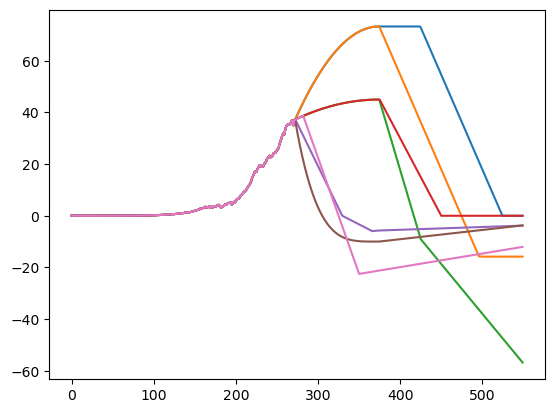

In [7]:
pl.plot(f.emissions.sel(specie = "CO2 FFI", config = 1234))

In [8]:
fancy_titles = {
    "high-extension": "High Extension",
    "high-overshoot": "High Overshoot",
    "medium-overshoot": "Medium Overshoot",
    "medium-extension": "Medium Extension",
    "low": "Low",
    "verylow": "Very Low",
    "verylow-overshoot": "Very Low Overshoot",
}

colors = {
    "high-extension": "#8B0000",        # Dark red
    "high-overshoot": "#DC143C",        # Crimson
    "medium-overshoot": "#FF4500",      # Orange red
    "medium-extension": "#FFA500",      # Orange
    "low": "#00BFFF",                   # Deep sky blue
    "verylow": "#4169E1",               # Royal blue
    "verylow-overshoot": "#0000FF",     # Dark blue
}

weights_51yr = np.ones(52)
weights_51yr[0] = 0.5
weights_51yr[-1] = 0.5

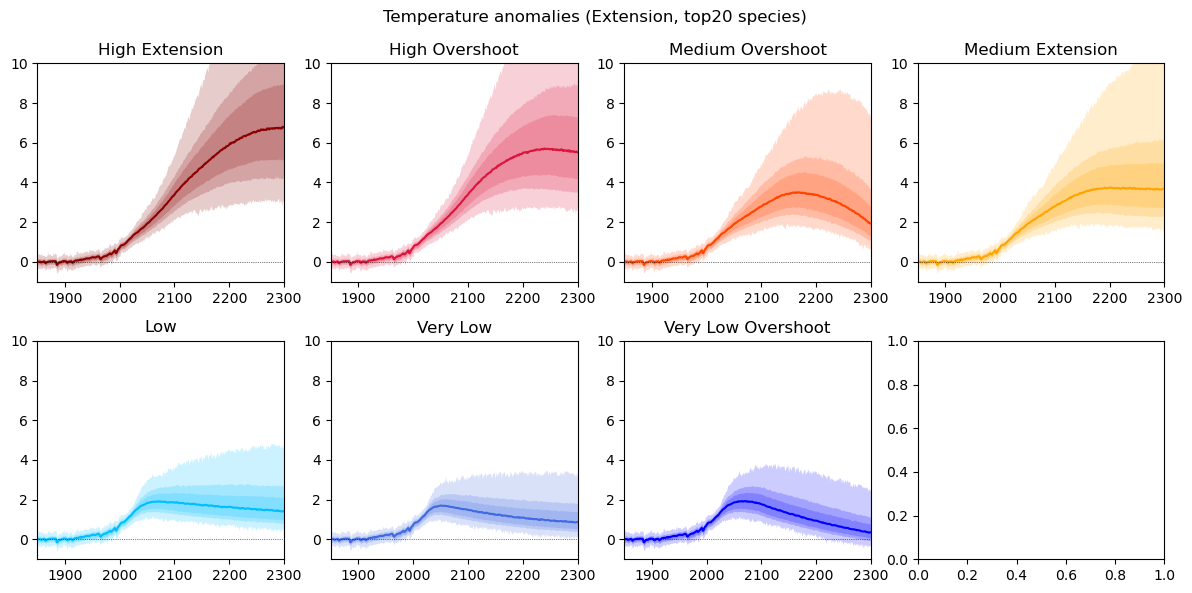

In [9]:
fig, ax = pl.subplots(2, 4, figsize=(12, 6))

for i, scenario in enumerate(f.scenarios):
    for pp in ((0, 100), (5, 95), (16, 84)):
        ax[i // 4, i % 4].fill_between(
            f.timebounds,
            np.percentile(
                f.temperature.loc[dict(scenario=scenario, layer=0)]
                - np.average(
                    f.temperature.loc[
                        dict(scenario=scenario, timebounds=np.arange(1850, 1902), layer=0)
                    ],
                    weights=weights_51yr,
                    axis=0
                ),
                pp[0],
                axis=1,
            ),
            np.percentile(
                f.temperature.loc[dict(scenario=scenario, layer=0)]
                - np.average(
                    f.temperature.loc[
                        dict(scenario=scenario, timebounds=np.arange(1850, 1902), layer=0)
                    ],
                    weights=weights_51yr,
                    axis=0
                ),
                pp[1],
                axis=1,
            ),
            color=colors[f.scenarios[i]],
            alpha=0.2,
            lw=0
        )

    ax[i // 4, i % 4].plot(
        f.timebounds,
        np.median(
            f.temperature.loc[dict(scenario=scenario, layer=0)]
            - np.average(
                f.temperature.loc[
                    dict(scenario=scenario, timebounds=np.arange(1850, 1902), layer=0)
                ],
                weights=weights_51yr,
                axis=0
            ),
            axis=1,
        ),
        color=colors[f.scenarios[i]],
    )
    ax[i // 4, i % 4].set_xlim(1850, 2300)
    ax[i // 4, i % 4].set_ylim(-1, 10)
    ax[i // 4, i % 4].axhline(0, color="k", ls=":", lw=0.5)
    ax[i // 4, i % 4].set_title(fancy_titles[f.scenarios[i]])

pl.suptitle("Temperature anomalies (Extension, top20 species)")
fig.tight_layout()

In [ ]:
# save fair object
import pickle

with open("/glade/work/stevenxu/FAIR_models/origional_model_extension.pkl", "wb") as f_out:
    pickle.dump(f, f_out)